In [86]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import warnings
warnings.filterwarnings("ignore")
import random

In [57]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [58]:
df = pd.DataFrame(X, columns=['col1', 'col2', 'col3', 'col4', 'col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-2.476864,1.695336,0.777821,-3.563836,-0.094311,1
1,0.800491,2.189677,2.815387,5.225159,1.670426,0
2,0.281530,2.000488,2.309456,2.281103,0.037687,0
3,0.401847,2.225420,2.761083,3.588447,0.583165,0
4,0.279615,0.921767,-0.280577,-0.473156,-2.349681,0


In [59]:
# Function for sampling the rows

def sample_rows(df, percent):
    return df.sample(int(percent*df.shape[0]),replace=True)

In [100]:
# Function for Feature Sampling

def sample_features(df,percent):
    cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
    new_df = df[cols]
    new_df['target'] = df['target']
    return new_df

In [101]:
# Function for combined sampling 

def combined_sampling(df,row_percent,col_percent):
    new_df = sample_rows(df,row_percent)
    return sample_features(new_df, col_percent)

### Row Sampling

In [89]:
# First dataset for first Decision Tree
df1 = sample_rows(df,0.2)

In [90]:
# Second dataset for Second Decision Tree
df2 = sample_rows(df,0.2)

In [91]:
# Third dataset for Third Decision Tree
df3 = sample_rows(df,0.2)

In [92]:
df3.head()

,col1,col2,col3,col4,col5,target
29,-0.125267,0.987553,2.617173,-1.649020,0.875982,1
49,1.009980,3.288139,2.689673,3.533550,-2.752238,0
73,1.428040,-0.629149,-0.861237,-1.462224,-1.672783,0
39,0.710496,2.142103,1.761419,1.572605,-1.958188,0
26,-0.774083,-1.849923,1.292135,-0.676909,-1.221355,1


### Column Sampling

In [102]:
df_col1 = sample_features(df,0.8)

In [103]:
df_col2 = sample_features(df,0.8)

In [104]:
df_col3 = sample_features(df,0.8)

In [105]:
df_col3

,col2,col1,col4,col3,target
0,1.695336,-2.476864,-3.563836,0.777821,1
1,2.189677,0.800491,5.225159,2.815387,0
2,2.000488,0.281530,2.281103,2.309456,0
3,2.225420,0.401847,3.588447,2.761083,0
4,0.921767,0.279615,-0.473156,-0.280577,0
...,...,...,...,...,...
95,1.605540,0.053718,0.531694,1.278987,0
96,-1.849764,-1.414280,-2.223291,0.574247,1
97,-0.937393,-1.375429,-0.948943,1.784683,1
98,-3.360876,1.122159,-1.814276,-1.317351,1


In [112]:
print(df_col1.columns)
print(df_col2.columns)
print(df_col3.columns)

Index(['col4', 'col3', 'col1', 'col2', 'target'], dtype='object')
Index(['col5', 'col1', 'col3', 'col4', 'target'], dtype='object')
Index(['col2', 'col1', 'col4', 'col3', 'target'], dtype='object')


In [113]:
df_col3

,col2,col1,col4,col3,target
0,1.695336,-2.476864,-3.563836,0.777821,1
1,2.189677,0.800491,5.225159,2.815387,0
2,2.000488,0.281530,2.281103,2.309456,0
3,2.225420,0.401847,3.588447,2.761083,0
4,0.921767,0.279615,-0.473156,-0.280577,0
...,...,...,...,...,...
95,1.605540,0.053718,0.531694,1.278987,0
96,-1.849764,-1.414280,-2.223291,0.574247,1
97,-0.937393,-1.375429,-0.948943,1.784683,1
98,-3.360876,1.122159,-1.814276,-1.317351,1


In [66]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

### Decision Tree for Rows

In [67]:
clf1.fit(df1.iloc[:,0:5], df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:5], df3.iloc[:,-1])
clf3.fit(df3.iloc[:,0:5], df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

### Decision Tree for Columns

In [107]:
from sklearn.tree import DecisionTreeClassifier
cl1 = DecisionTreeClassifier()
cl2 = DecisionTreeClassifier()
cl3 = DecisionTreeClassifier()

In [118]:
cl1.fit(df_col1.iloc[:,0:4], df_col1.iloc[:,-1])
cl2.fit(df_col2.iloc[:,0:4], df_col2.iloc[:,-1])
cl3.fit(df_col3.iloc[:,0:4], df_col3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [68]:
from sklearn.tree import plot_tree

[Text(0.6, 0.875, 'x[0] <= 0.746\ngini = 0.5\nsamples = 20\nvalue = [10, 10]'),
 Text(0.4, 0.625, 'x[1] <= 1.438\ngini = 0.278\nsamples = 12\nvalue = [2, 10]'),
 Text(0.5, 0.75, 'True  '),
 Text(0.2, 0.375, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.6, 0.375, 'x[3] <= -0.702\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.4, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.8, 0.625, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.7, 0.75, '  False')]

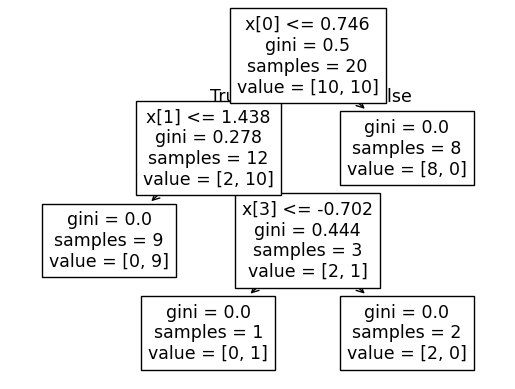

In [69]:
plot_tree(clf1)

[Text(0.4090909090909091, 0.875, 'x[1] <= -1.084\ngini = 0.455\nsamples = 20\nvalue = [7, 13]'),
 Text(0.18181818181818182, 0.625, 'x[1] <= -1.984\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.29545454545454547, 0.75, 'True  '),
 Text(0.09090909090909091, 0.375, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2727272727272727, 0.375, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.6363636363636364, 0.625, 'x[1] <= 2.071\ngini = 0.375\nsamples = 16\nvalue = [4, 12]'),
 Text(0.5227272727272727, 0.75, '  False'),
 Text(0.45454545454545453, 0.375, 'x[4] <= 0.092\ngini = 0.153\nsamples = 12\nvalue = [1, 11]'),
 Text(0.36363636363636365, 0.125, 'gini = 0.0\nsamples = 11\nvalue = [0, 11]'),
 Text(0.5454545454545454, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8181818181818182, 0.375, 'x[2] <= 2.719\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.7272727272727273, 0.125, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.9090909090909091, 0.125, 'gini = 0.

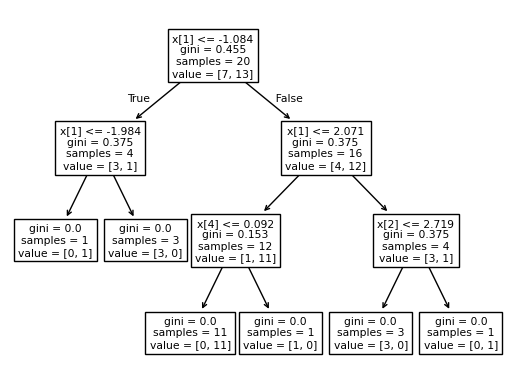

In [70]:
plot_tree(clf2)

[Text(0.4, 0.8333333333333334, 'x[0] <= 0.11\ngini = 0.455\nsamples = 20\nvalue = [7, 13]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 11\nvalue = [0, 11]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[1] <= -0.824\ngini = 0.346\nsamples = 9\nvalue = [7, 2]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]')]

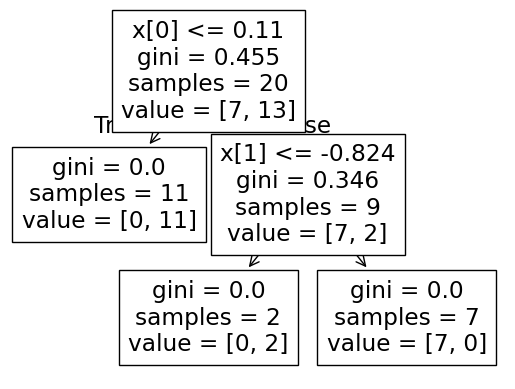

In [71]:
plot_tree(clf3)

[Text(0.36666666666666664, 0.9285714285714286, 'x[2] <= -0.478\ngini = 0.5\nsamples = 100\nvalue = [49, 51]'),
 Text(0.13333333333333333, 0.7857142857142857, 'x[0] <= 0.395\ngini = 0.095\nsamples = 40\nvalue = [2, 38]'),
 Text(0.25, 0.8571428571428572, 'True  '),
 Text(0.06666666666666667, 0.6428571428571429, 'gini = 0.0\nsamples = 37\nvalue = [0, 37]'),
 Text(0.2, 0.6428571428571429, 'x[1] <= 1.254\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.13333333333333333, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.26666666666666666, 0.5, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.6, 0.7857142857142857, 'x[3] <= -0.854\ngini = 0.339\nsamples = 60\nvalue = [47, 13]'),
 Text(0.4833333333333333, 0.8571428571428572, '  False'),
 Text(0.4666666666666667, 0.6428571428571429, 'x[0] <= -2.369\ngini = 0.18\nsamples = 10\nvalue = [1, 9]'),
 Text(0.4, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.5333333333333333, 0.5, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 T

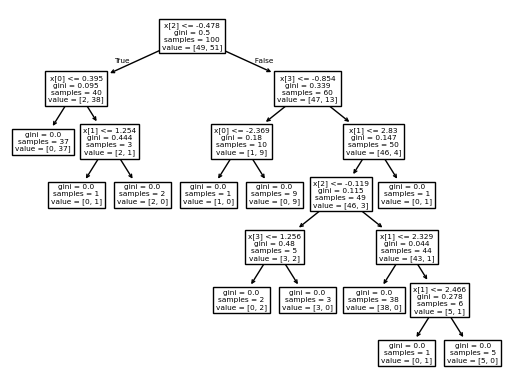

In [109]:
plot_tree(cl1)

[Text(0.39285714285714285, 0.9444444444444444, 'x[1] <= -0.478\ngini = 0.5\nsamples = 100\nvalue = [49, 51]'),
 Text(0.14285714285714285, 0.8333333333333334, 'x[0] <= 0.097\ngini = 0.095\nsamples = 40\nvalue = [2, 38]'),
 Text(0.26785714285714285, 0.8888888888888888, 'True  '),
 Text(0.07142857142857142, 0.7222222222222222, 'gini = 0.0\nsamples = 37\nvalue = [0, 37]'),
 Text(0.21428571428571427, 0.7222222222222222, 'x[3] <= -0.702\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.14285714285714285, 0.6111111111111112, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2857142857142857, 0.6111111111111112, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.6428571428571429, 0.8333333333333334, 'x[1] <= 0.666\ngini = 0.339\nsamples = 60\nvalue = [47, 13]'),
 Text(0.5178571428571429, 0.8888888888888888, '  False'),
 Text(0.5, 0.7222222222222222, 'x[3] <= 2.059\ngini = 0.493\nsamples = 25\nvalue = [14.0, 11.0]'),
 Text(0.42857142857142855, 0.6111111111111112, 'x[2] <= 2.048\ngini = 0

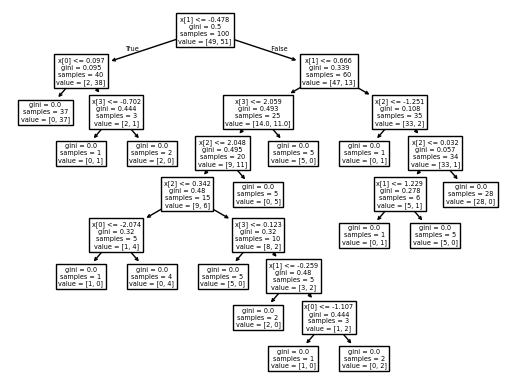

In [110]:
plot_tree(cl2)

[Text(0.5, 0.75, 'x[4] <= 0.5\ngini = 0.5\nsamples = 100\nvalue = [49, 51]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 49\nvalue = [49, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 51\nvalue = [0, 51]'),
 Text(0.625, 0.5, '  False')]

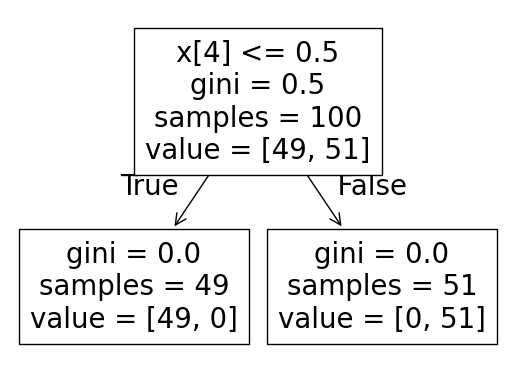

In [111]:
plot_tree(cl3)

In [72]:
# -2.970146	-3.796177	0.935162	0.163385	-5.856482
clf1.predict(np.array([-2.970146, -3.796177, 0.935162, 0.163385, -5.856482]).reshape(1,5))

array([1])

In [73]:
clf2.predict(np.array([-2.970146, -3.796177, 0.935162, 0.163385, -5.856482]).reshape(1,5))

array([1])

In [74]:
clf3.predict(np.array([-2.970146, -3.796177, 0.935162, 0.163385, -5.856482]).reshape(1,5))

array([1])

In [115]:
# 1.695336	-2.476864	-3.563836	0.777821	
cl1.predict(np.array([1.695336, -2.476864, -3.563836, 0.777821]).reshape(1,4))

array([1])

In [116]:
# 1.695336	-2.476864	-3.563836	0.777821	
cl2.predict(np.array([1.695336, -2.476864, -3.563836, 0.777821]).reshape(1,4))

array([0])

In [119]:
# 1.695336	-2.476864	-3.563836	0.777821	
cl3.predict(np.array([1.695336, -2.476864, -3.563836, 0.777821]).reshape(1,4))

array([1])

### Combined Sampling

In [121]:
cs1 = combined_sampling(df, 0.5, 0.5)

In [122]:
cs2 = combined_sampling(df, 0.5, 0.5)

In [123]:
cs3 = combined_sampling(df, 0.5, 0.5)

In [124]:
cs3

,col4,col3,target
7,-1.569932,0.255060,1
14,0.340265,-0.329570,1
73,-1.462224,-0.861237,0
61,1.703488,0.482065,0
88,-0.762718,2.750357,1
92,0.393884,2.398630,1
38,-2.910292,0.265049,1
62,1.906024,2.844751,1
74,2.265355,1.282287,0
73,-1.462224,-0.861237,0


In [125]:
print(cs1.columns)
print(cs2.columns)
print(cs3.columns)

Index(['col2', 'col5', 'target'], dtype='object')
Index(['col2', 'col1', 'target'], dtype='object')
Index(['col4', 'col3', 'target'], dtype='object')


In [ ]:
cs_1 = DecisionTreeClassifier()
cs_2 = DecisionTreeClassifier()
cs_3 = DecisionTreeClassifier()

In [138]:
cs_1.fit(cs1.iloc[:,0:2], cs1.iloc[:,-1])
cs_2.fit(cs2.iloc[:,0:2], cs2.iloc[:,-1])
cs_3.fit(cs3.iloc[:,0:2], cs3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

[Text(0.2857142857142857, 0.9285714285714286, 'x[0] <= -0.762\ngini = 0.471\nsamples = 50\nvalue = [19, 31]'),
 Text(0.14285714285714285, 0.7857142857142857, 'gini = 0.0\nsamples = 19\nvalue = [0, 19]'),
 Text(0.21428571428571427, 0.8571428571428572, 'True  '),
 Text(0.42857142857142855, 0.7857142857142857, 'x[1] <= -1.208\ngini = 0.475\nsamples = 31\nvalue = [19, 12]'),
 Text(0.3571428571428571, 0.8571428571428572, '  False'),
 Text(0.2857142857142857, 0.6428571428571429, 'gini = 0.0\nsamples = 11\nvalue = [11, 0]'),
 Text(0.5714285714285714, 0.6428571428571429, 'x[0] <= 1.397\ngini = 0.48\nsamples = 20\nvalue = [8, 12]'),
 Text(0.42857142857142855, 0.5, 'x[0] <= -0.519\ngini = 0.32\nsamples = 15\nvalue = [3, 12]'),
 Text(0.2857142857142857, 0.35714285714285715, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.5714285714285714, 0.35714285714285715, 'x[1] <= -0.637\ngini = 0.142\nsamples = 13\nvalue = [1, 12]'),
 Text(0.42857142857142855, 0.21428571428571427, 'gini = 0.0\nsamples = 

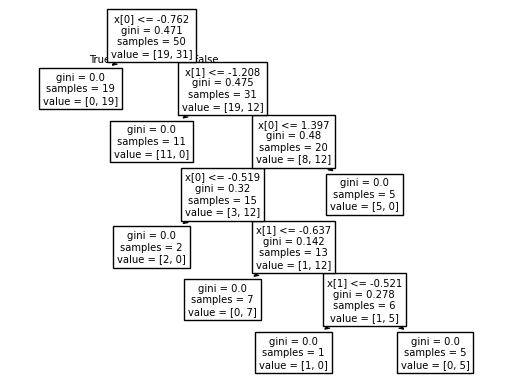

In [139]:
plot_tree(cs_1)

[Text(0.5, 0.9166666666666666, 'x[0] <= 0.336\ngini = 0.497\nsamples = 50\nvalue = [23, 27]'),
 Text(0.25, 0.75, 'x[1] <= 1.229\ngini = 0.165\nsamples = 22\nvalue = [2, 20]'),
 Text(0.375, 0.8333333333333333, 'True  '),
 Text(0.125, 0.5833333333333334, 'gini = 0.0\nsamples = 20\nvalue = [0, 20]'),
 Text(0.375, 0.5833333333333334, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.75, 0.75, 'x[1] <= 0.078\ngini = 0.375\nsamples = 28\nvalue = [21, 7]'),
 Text(0.625, 0.8333333333333333, '  False'),
 Text(0.625, 0.5833333333333334, 'x[0] <= 1.246\ngini = 0.486\nsamples = 12\nvalue = [5, 7]'),
 Text(0.5, 0.4166666666666667, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.75, 0.4166666666666667, 'x[1] <= -0.958\ngini = 0.278\nsamples = 6\nvalue = [5, 1]'),
 Text(0.625, 0.25, 'x[0] <= 2.36\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.5, 0.08333333333333333, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.75, 0.08333333333333333, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 T

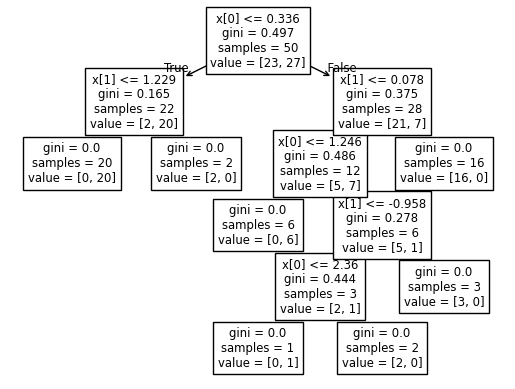

In [140]:
plot_tree(cs_2)

[Text(0.5, 0.9, 'x[0] <= 0.442\ngini = 0.385\nsamples = 50\nvalue = [13, 37]'),
 Text(0.25, 0.7, 'x[1] <= -0.595\ngini = 0.114\nsamples = 33\nvalue = [2, 31]'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'gini = 0.0\nsamples = 31\nvalue = [0, 31]'),
 Text(0.75, 0.7, 'x[1] <= 2.83\ngini = 0.457\nsamples = 17\nvalue = [11, 6]'),
 Text(0.625, 0.8, '  False'),
 Text(0.625, 0.5, 'x[0] <= 1.628\ngini = 0.153\nsamples = 12\nvalue = [11, 1]'),
 Text(0.5, 0.3, 'x[0] <= 1.464\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.375, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.625, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.75, 0.3, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.875, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]')]

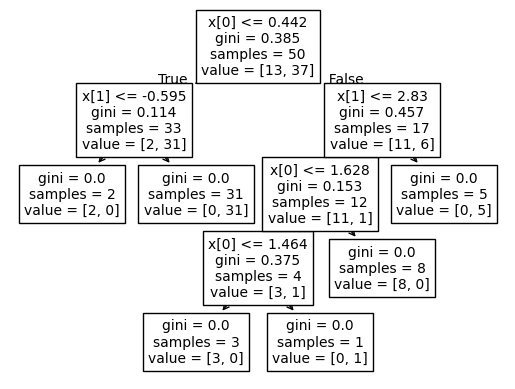

In [141]:
plot_tree(cs_3)

In [142]:
# -0.434513	2.040545		
cs_1.predict(np.array([-0.434513, 2.040545	]).reshape(1,2))

array([1])

In [143]:
# -0.434513	2.040545		
cs_2.predict(np.array([-0.434513, 2.040545	]).reshape(1,2))

array([0])

In [144]:
# -0.434513,	2.040545		
cs_3.predict(np.array([-0.434513, 2.040545	]).reshape(1,2))

array([1])